In [5]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI   
from dotenv import load_dotenv


In [6]:
load_dotenv()  # Load environment variables from .env file
model=ChatGoogleGenerativeAI(model="gemini-2.5-flash-preview-05-20")

In [7]:
#Defining the state
class LLMState(TypedDict):
    topic:str
    outline:str
    content:str
    

In [8]:
def create_outline(state:LLMState)->LLMState:
    prompt=f"Create a detailed outline for a blog post about {state['topic']}"
    outline=model.invoke(prompt)
    state['outline']=outline.content
    return state

In [9]:
def create_content(state:LLMState)->LLMState:
    prompt=f"Write a detailed blog post based on the following outline:\n{state['outline']}"
    content=model.invoke(prompt)
    state['content']=content.content
    return state

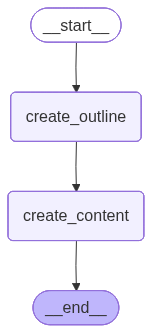

In [11]:
# Define the graph
graph=StateGraph(LLMState)

#add the nodes
graph.add_node("create_outline",create_outline)
graph.add_node("create_content",create_content)

#add the edges
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_content")
graph.add_edge("create_content",END)

#complie the graph
result=graph.compile()
result

In [15]:
input={'topic':'Artificial Intelligence'}
output=result.invoke(input)
print(output)
print(output['content'])

{'topic': 'Artificial Intelligence', 'outline': 'Here\'s a detailed outline for a blog post about Artificial Intelligence, designed to be informative, engaging, and comprehensive for a general audience.\n\n---\n\n## Blog Post Title: Unlocking the Power of AI: Everything You Need to Know About Artificial Intelligence\n\n**Target Audience:** General public, tech enthusiasts, professionals interested in understanding AI\'s impact.\n**Tone:** Informative, accessible, slightly enthusiastic, balanced (acknowledging both benefits and challenges).\n**Goal:** To demystify AI, explain its core concepts, showcase its applications, and discuss its future implications.\n\n---\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Catchy Hook:** Start with a relatable scenario where AI is already present (e.g., "Ever asked Siri a question, gotten a Netflix recommendation, or had your email filter out spam? Then you\'ve interacted with Artificial Intelligence.").\n*   **B. Brief Definition:** Wha

In [16]:
print(output['content'])

## Unlocking the Power of AI: Everything You Need to Know About Artificial Intelligence

Ever asked Siri a question, gotten a Netflix recommendation, or had your email filter out spam? Then you've interacted with Artificial Intelligence. Far from being a futuristic concept confined to sci-fi movies, AI is already an integral part of our daily lives, quietly powering many of the technologies we rely on. At its core, AI refers to machines mimicking human intelligence to perform tasks, solve problems, and learn from experience.

The rapid advancements in AI over the past decade mean it's no longer just a buzzword; it's a transformative force reshaping industries, economies, and societies worldwide. Understanding AI is no longer a niche interest for tech enthusiasts—it's becoming essential for everyone. This post will demystify what AI is, how it works, its incredible applications, and the vital discussions we need to have about its future to ensure it benefits all of humanity.

---

### W